In [1]:
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_3C

data = "dream_cytof"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename="evaluate_all_figure3c"), index_col=0).assign(model=model)
    for model in PATHWAYS_3C
)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)


In [2]:
val_df[val_df.ref == "DMM"].groupby(["model", "context", "n_hidden"]).rmse.mean()

model                           context     n_hidden
EGFR_MAPK__logobs               cytof_init  1.0         0.605612
                                            2.0         0.584546
                                            3.0         0.558903
                                            4.0         0.558862
                                            6.0         0.535017
                                            8.0         0.560689
                                            10.0        0.527556
                                            15.0        0.518364
                                            20.0        0.528406
                                            25.0        0.530613
                                            30.0        0.525278
                                multimodal  1.0         0.587931
                                            2.0         0.554638
                                            3.0         0.558532
                                     

In [3]:
val_df[val_df.ref == "DMM"].groupby(["model", "context", "n_hidden"]).rmse.median()

model                           context     n_hidden
EGFR_MAPK__logobs               cytof_init  1.0         0.576072
                                            2.0         0.562474
                                            3.0         0.544351
                                            4.0         0.548593
                                            6.0         0.523889
                                            8.0         0.562216
                                            10.0        0.511666
                                            15.0        0.506565
                                            20.0        0.512247
                                            25.0        0.510538
                                            30.0        0.515326
                                multimodal  1.0         0.586500
                                            2.0         0.527231
                                            3.0         0.545902
                                     

# Varying `n_hidden` for linear models (`depth=0`)

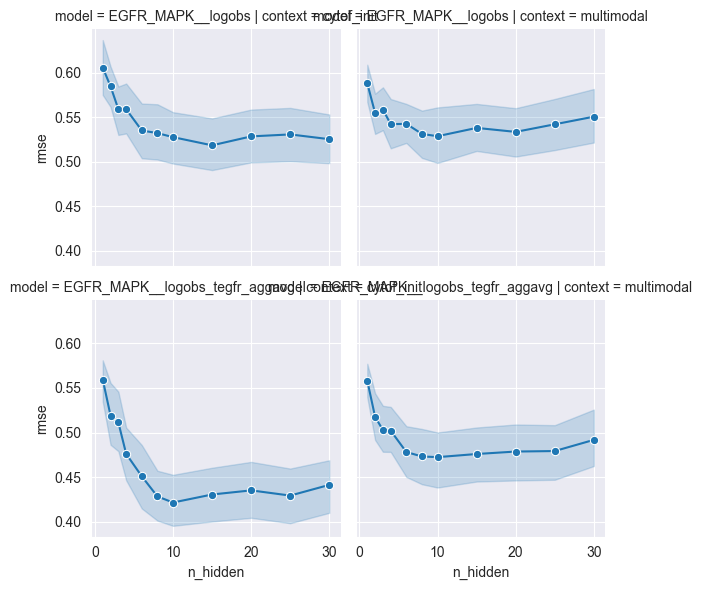

In [4]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o'
)

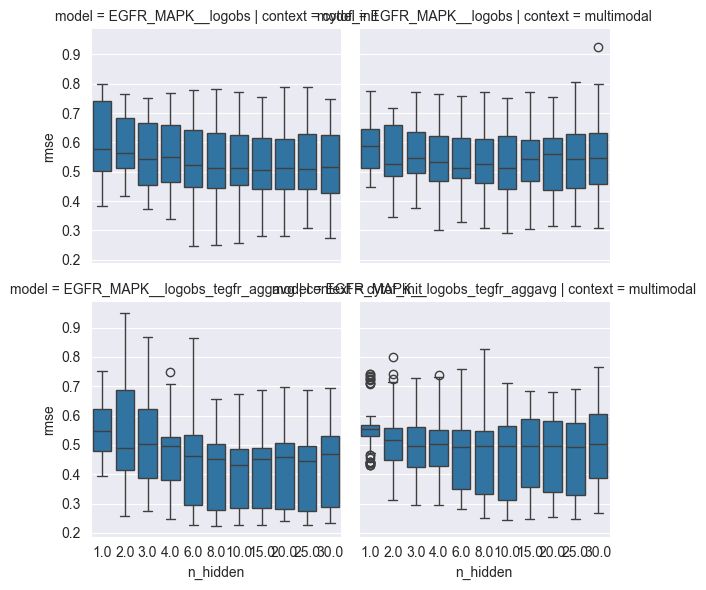

In [5]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
)

g.map_dataframe(
    sns.boxplot,
    x="n_hidden",
    y="rmse",
)

In [6]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    num_contexts = int(len(df['context'].unique()))
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}; < 0.05/{num_contexts}={0.05/num_contexts}?: {p_value < 0.05/num_contexts}")

In [7]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
    ],
    "rmse",
    "n_hidden"
)

Context: multimodal - Kruskal-Wallis H-test: H-statistic=41.57, p-value=0.0000; < 0.05/2=0.025?: True
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=101.68, p-value=0.0000; < 0.05/2=0.025?: True


Statistically significant effect, but not if we consider values exceeding `n_hidden=8`

In [8]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
        & (val_df.n_hidden > 8)
    ],
    "rmse",
    "n_hidden"
)

Context: multimodal - Kruskal-Wallis H-test: H-statistic=1.59, p-value=0.8103; < 0.05/2=0.025?: False
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.63, p-value=0.9595; < 0.05/2=0.025?: False


For that region where `n_hidden` is not significant, `model` still is very significant

In [9]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
        & (val_df.n_hidden > 8)
    ],
    "rmse",
    "model"
)

Context: multimodal - Kruskal-Wallis H-test: H-statistic=27.07, p-value=0.0000; < 0.05/2=0.025?: True
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=73.64, p-value=0.0000; < 0.05/2=0.025?: True


We can look at the gain from base to tEGFR model at each `n_hidden` value

Text(0.5, 1.05, 'RMSE difference between models vs n_hidden')

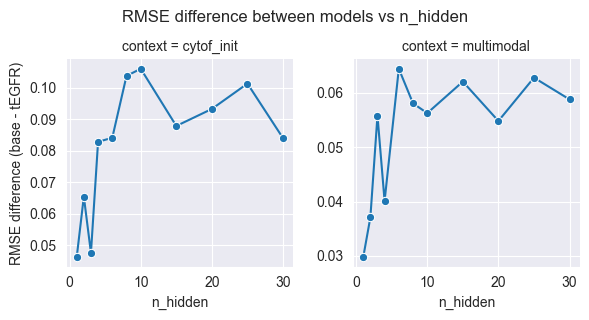

In [10]:
subset = val_df[
    (val_df.ref == "DMM")
    & (val_df.dropout_rate == 0.1)
    & (val_df.recon_loss == 1e-4)
    & (val_df.depth == 0)
    & (val_df.l1reg_inflater_output == 1e-2)
    & (val_df.l2reg_inflater_output == 0)
]

pivot = (
    subset
    .pivot_table(
        index=["context", "n_hidden"],
        columns="model",
        values="rmse"
    )
    .reset_index()
)

pivot["rmse_diff"] = (
    pivot["EGFR_MAPK__logobs"]
    - pivot["EGFR_MAPK__logobs_tegfr_aggavg"]
)

g = sns.FacetGrid(
    pivot,
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse_diff",
    marker="o"
)
g.set_axis_labels("n_hidden", "RMSE difference (base - tEGFR)")
g.fig.suptitle("RMSE difference between models vs n_hidden", y=1.05)

# Varying `depth` (at fixed `n_hidden=8`)

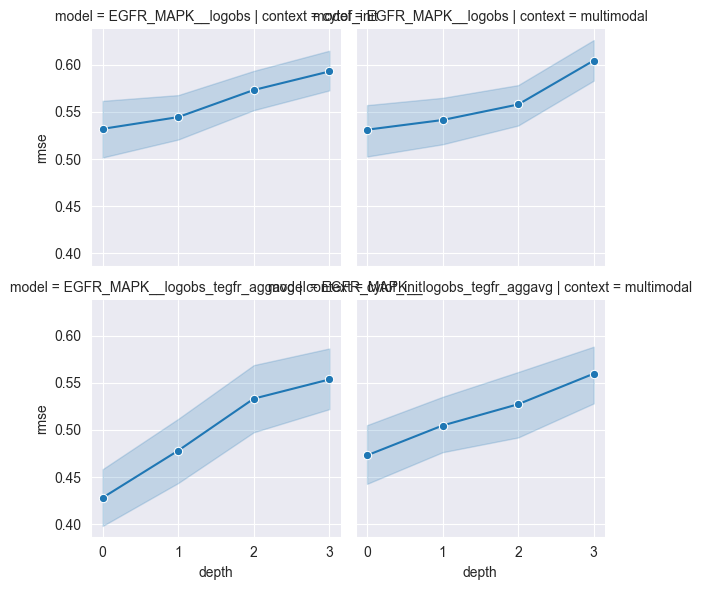

In [11]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.n_hidden == 8) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o'
)

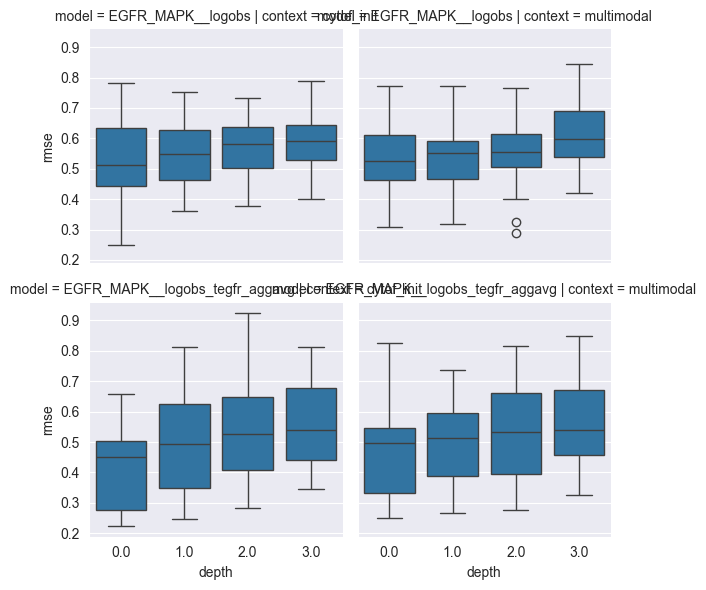

In [12]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.n_hidden == 8) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
)

g.map_dataframe(
    sns.boxplot,
    x="depth",
    y="rmse",
)

In [13]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
    ],
    "rmse",
    "depth"
)

Context: multimodal - Kruskal-Wallis H-test: H-statistic=31.45, p-value=0.0000; < 0.05/2=0.025?: True
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=44.15, p-value=0.0000; < 0.05/2=0.025?: True
